In [1]:
import functions
import shap
import optuna

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from keras.callbacks import EarlyStopping
from keras.datasets import mnist
import numpy as np
import pandas as pd

import os
os.getcwd()

ModuleNotFoundError: No module named 'functions'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df, path_name, _ = functions.Kaggle1(id_number=0)
X_train, y_train, X_val, y_val, X_test, y_test = functions.load_and_preprocess_data_with_sequences(df, val_ratio=0.1, test_ratio=0.10, input_seq_length=48, output_seq_length=24)
data = (X_train, X_val, X_test, y_train, y_val, y_test)

opt_results = pd.read_csv("Kaggle1_optimization_results.csv")
model, y_pred = functions.train_with_best_hyperparameters(opt_results['best_params'][0], data, functions.create_lstm_model)


2024-06-01 18:20:40.742863: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31141 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:b2:00.0, compute capability: 7.0
2024-06-01 18:20:41.121562: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-06-01 18:20:43.381768: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905
2024-06-01 18:20:44.544754: I external/local_xla/xla/service/service.cc:168] XLA service 0x2abdcea2f980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-06-01 18:20:44.544799: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
2024-06-01 18:20:44.550411: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set

Restoring model weights from the end of the best epoch: 42.
Epoch 47: early stopping
181/181 [==============================] - 1s 4ms/step


181/181 [==============================] - 1s 4ms/step


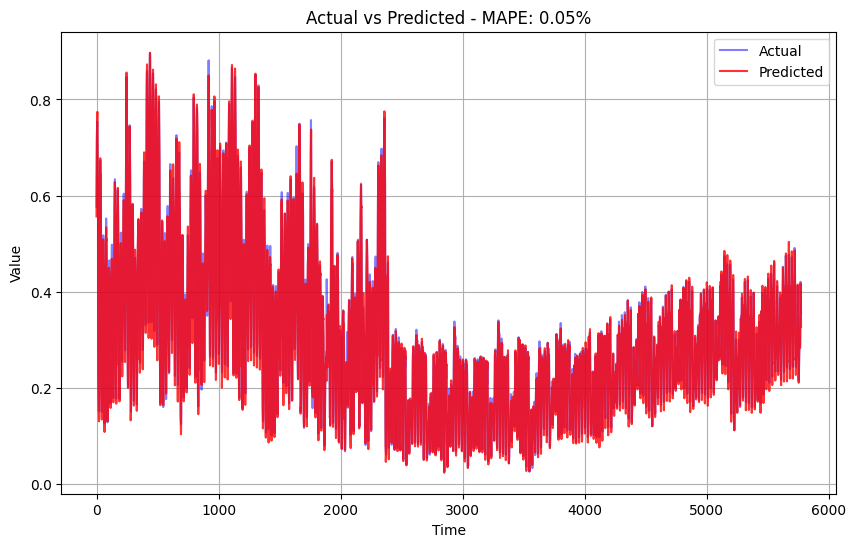

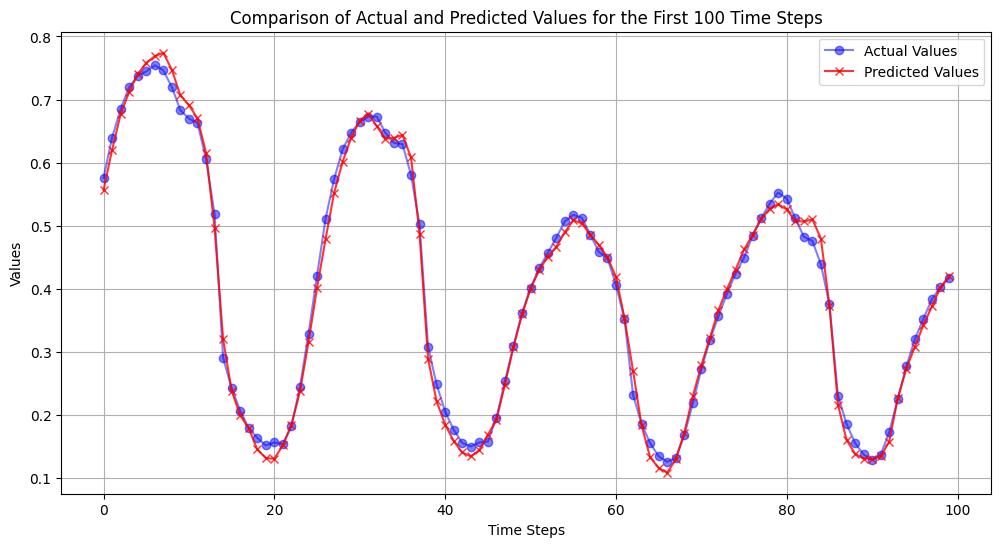

In [ ]:
functions.plot_predictions(model, X_test, y_test, i=0, j=100, save_to_pdf=False, pdf_filename="predictions.pdf", real_transparency=0.5, pred_transparency=0.8)


In [ ]:
import numpy as np
import pandas as pd
import shap
from sklearn.neighbors import NearestNeighbors

# Function to find the most relevant background data based on cosine similarity
def select_relevant_background_data(X_train, test_instance, num_neighbors=10):
    test_instance_flattened = test_instance.flatten().reshape(1, -1)
    X_train_flattened = X_train.reshape(X_train.shape[0], -1)

    # Compute cosine similarity
    knn = NearestNeighbors(n_neighbors=num_neighbors, metric='cosine')
    knn.fit(X_train_flattened)
    distances, indices = knn.kneighbors(test_instance_flattened)

    return X_train[indices[0]]

# Function to calculate SHAP values
def my_shap(model, background_training, new_data, general_method=0.01, horizon=0, similar_background=False, num_neighbors=100):
    if similar_background:
        background_training = select_relevant_background_data(background_training, new_data, num_neighbors=num_neighbors)
    else:
        background_training = background_training[:int(background_training.shape[0] * general_method)]

    # Prepare background data (flattened for KernelExplainer)
    background_data = background_training.reshape(background_training.shape[0], -1)  # Flatten to 2D matrix
    test_data = new_data.reshape(new_data.shape[0], -1)  # Flatten to 2D matrix for explanation

    # Define a prediction function that reshapes the 2D input back to 3D
    def model_predict(data):
        reshaped_data = data.reshape((-1, new_data.shape[1], new_data.shape[2]))
        return model.predict(reshaped_data)

    # Initialize the SHAP KernelExplainer
    explainer = shap.KernelExplainer(model_predict, background_data)

    # Calculate SHAP values
    shap_values = explainer.shap_values(test_data)

    # Create DataFrame for SHAP values
    shap_df = pd.DataFrame(shap_values[horizon].reshape(new_data.shape[1], new_data.shape[2]))

    result = {'explainer': explainer, 'shap_values': shap_values, 'shap_df': shap_df}
    return result

# Example usage
# Assuming you have a trained model, X_train as the training data, and new_data for which you want to explain predictions

# model = your_trained_model
# X_train = your_training_data
# new_data = your_test_data

# Example input shapes:
# X_train.shape -> (num_samples, sequence_length, num_features)
# new_data.shape -> (num_samples, sequence_length, num_features)

# result = my_shap(model, X_train, new_data, general_method=0.01, horizon=0, similar_background=True, num_neighbors=100)

result = my_shap(model, background_training = X_train, new_data = X_test[:1], general_method = 0.001, horizon = 0, similar_background=True, num_neighbors=100)

# Visualizing the SHAP values
shap_df = result['shap_df']
shap_values = result['shap_values']
explainer = result['explainer']

# Example: Bar plot for the first instance
shap.initjs()
shap_values_instance = shap_values[0]
shap.force_plot(explainer.expected_value, shap_values_instance, new_data[0])


4/4 [==============================] - 0s 4ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

9213/9213 [==============================] - 33s 4ms/step


In [ ]:
# Use the best hyperparameters to train the final model and make predictions
model, y_pred = train_with_best_hyperparameters(params_load['best_params'][2], data, create_lstm_model)
# model
# best_trial.duration.total_seconds()

# import datetime

# # Given timedelta object
# time_delta = datetime.timedelta(seconds=526, microseconds=127576)

# # Convert to seconds
# total_seconds = time_delta.total_seconds()

# print(total_seconds)
